In [1]:
import librosa

In [2]:
y, sr = librosa.load('sample_audio.mp3')

In [3]:
duration = len(y)/sr
duration

30.484897959183673

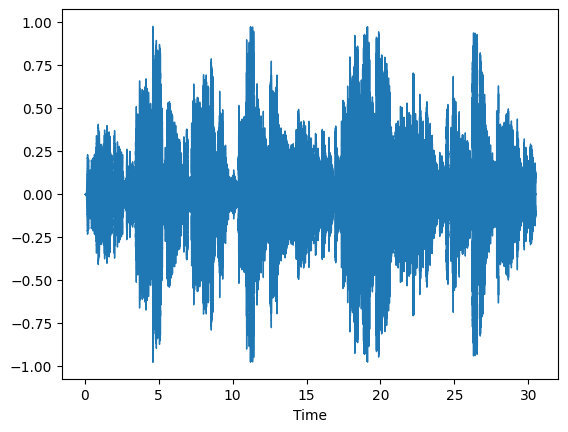

In [4]:
librosa.display.waveshow(y, sr=sr)

In [5]:
rms = librosa.feature.rms(y=y)
rms.shape

(1, 1313)

In [6]:
rms.mean()

np.float32(0.15605588)

In [7]:
import numpy as np
frames = np.arange(rms.shape[1])
time_ms = ((frames * 512)/sr)*1000

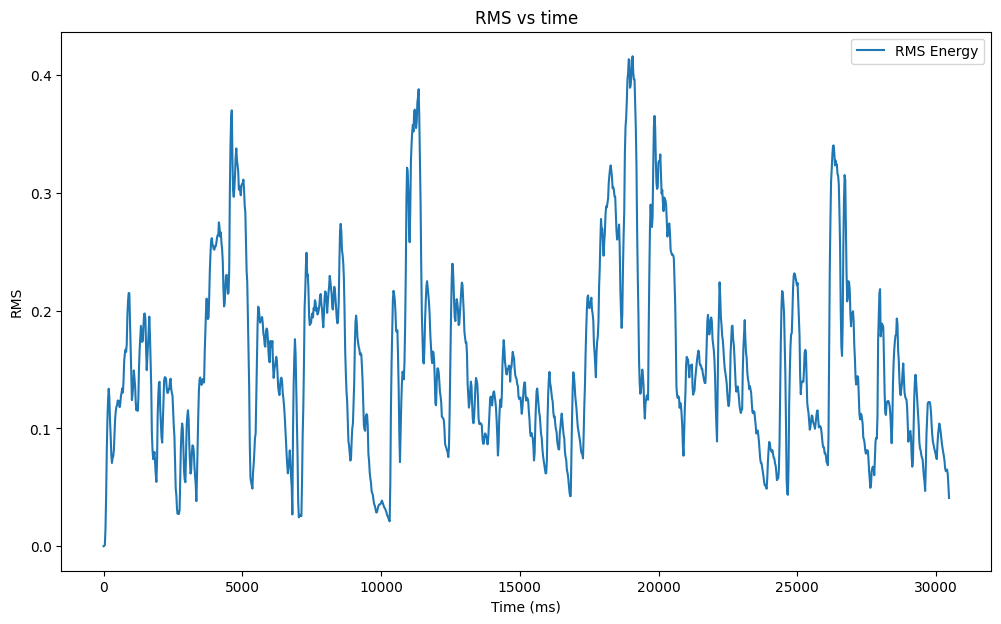

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
plt.plot(time_ms, rms[0], label='RMS Energy')
plt.xlabel('Time (ms)')
plt.ylabel('RMS')
plt.title('RMS vs time')
plt.legend()
plt.show()

In [9]:
vocals_y, vocals_sr = librosa.load("../data/stems/gehra-hua/mdx_extra_q/gehra-hua/vocals.mp3")
bass_y, bass_sr = librosa.load("../data/stems/gehra-hua/mdx_extra_q/gehra-hua/bass.mp3")
drums_y, drums_sr = librosa.load("../data/stems/gehra-hua/mdx_extra_q/gehra-hua/drums.mp3")
other_y, other_sr = librosa.load("../data/stems/gehra-hua/mdx_extra_q/gehra-hua/other.mp3")

In [10]:
vocals_rms = librosa.feature.rms(y=vocals_y)
bass_rms = librosa.feature.rms(y=bass_y)
drums_rms = librosa.feature.rms(y=drums_y)
other_rms = librosa.feature.rms(y=other_y)

vocals_frames = np.arange(vocals_rms.shape[1])
bass_frames = np.arange(bass_rms.shape[1])
drums_frames = np.arange(drums_rms.shape[1])
other_frames = np.arange(other_rms.shape[1])

time_ms = ((vocals_frames * 512)/sr) * 1000 

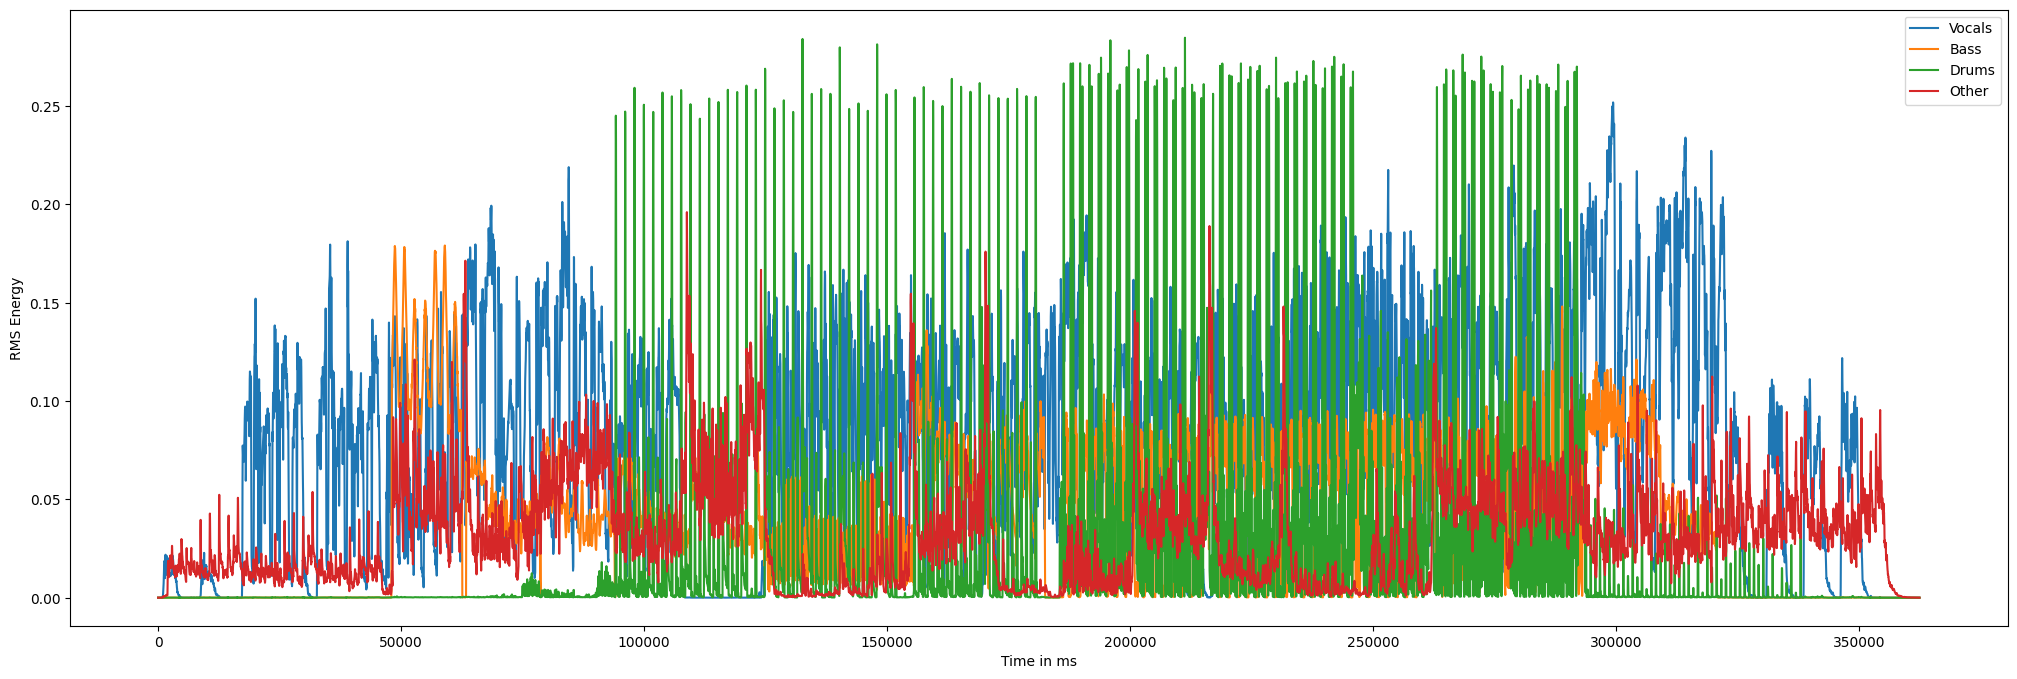

In [11]:
plt.figure(figsize=(25,8))
plt.plot(time_ms, vocals_rms[0], label = 'Vocals')
plt.plot(time_ms, bass_rms[0], label = 'Bass')
plt.plot(time_ms, drums_rms[0], label = 'Drums')
plt.plot(time_ms, other_rms[0], label = 'Other')
plt.xlabel('Time in ms')
plt.ylabel('RMS Energy')
plt.legend()
plt.show()

In [12]:
hz = librosa.yin(y, fmin=200, fmax=800)

In [13]:
notes = librosa.hz_to_note(hz)

In [14]:
librosa.onset.onset_detect(y=y, units='time')

array([ 0.11609977,  0.16253968,  1.06811791,  1.9969161 ,  2.83283447,
        3.41333333,  3.62231293,  4.41179138,  4.59755102,  4.73687075,
        5.43346939,  5.71210884,  5.94430839,  6.64090703,  6.84988662,
        7.03564626,  7.2214059 ,  7.33750567,  7.66258503,  8.10376417,
        8.52172336,  8.7539229 ,  8.98612245,  9.03256236,  9.82204082,
        9.93814059, 10.37931973, 10.61151927, 10.750839  , 10.95981859,
       11.07591837, 11.4706576 , 11.60997732, 12.07437642, 12.35301587,
       12.51555556, 12.97995465, 13.39791383, 13.81587302, 14.21061224,
       14.28027211, 14.41959184, 14.72145125, 15.16263039, 15.58058957,
       16.04498866, 16.4861678 , 16.90412698, 17.32208617, 17.36852608,
       17.74004535, 17.83292517, 18.08834467, 18.27410431, 18.66884354,
       18.92426304, 19.27256236, 19.38866213, 19.69052154, 20.87473923,
       21.19981859, 21.33913832, 21.4552381 , 21.78031746, 22.17505669,
       22.63945578, 23.08063492, 23.98621315, 24.42739229, 24.84

In [15]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(abs(D))

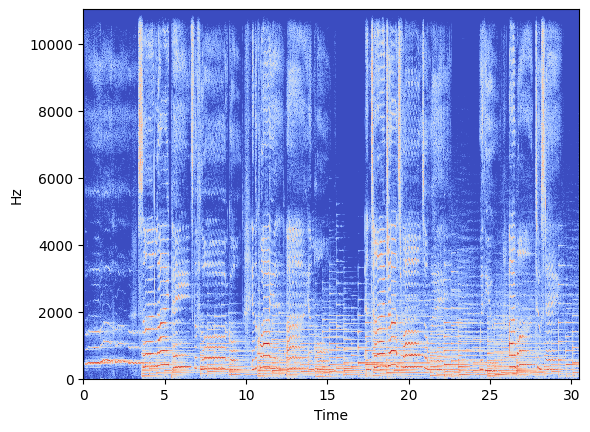

In [16]:
librosa.display.specshow(S_db, sr=sr,x_axis='time', y_axis='hz')

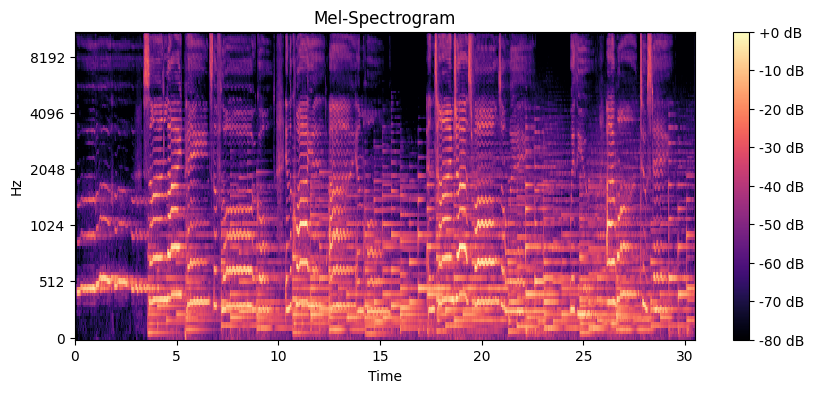

In [17]:
M = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
M_db = librosa.power_to_db(M, ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(M_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram")
plt.show()


In [18]:
def compute_mel_spectrogram(audio_path, n_mels=128, hop_length=512, n_fft=2048):
    """
    Compute the Mel-spectrogram of an audio file.

    Parameters
    ----------
    audio_path : str
        Path to the audio file to be analyzed.
    n_mels : int, optional (default=128)
        Number of Mel bands to generate. Higher values give finer resolution
        on the Mel scale, but increase computation and memory usage.
    hop_length : int, optional (default=512)
        Number of samples between successive frames. Controls the time resolution
        of the spectrogram. Smaller values give finer time detail but larger output.
    n_fft : int, optional (default=2048)
        Length of the FFT window. Controls the frequency resolution of the spectrogram.
        Larger values give finer frequency detail but increase computation.

    Returns
    -------
    M : np.ndarray [shape=(n_mels, n_frames)]
        Mel-spectrogram array, with Mel bands along rows and time frames along columns.
        Values represent power (energy) in each Mel band at each frame.
    """
    # Load audio
    y, sr = librosa.load(audio_path, sr=None)

    # Compute Mel-spectrogram
    M = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                       hop_length=hop_length, n_fft=n_fft)
    return M

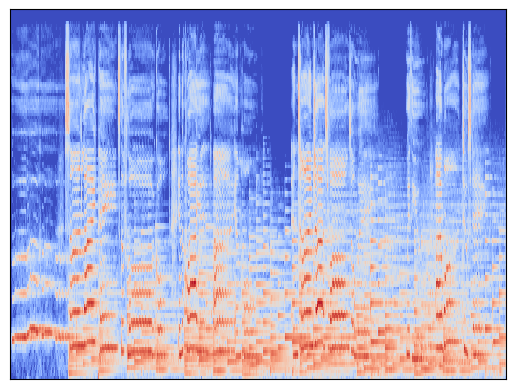

In [19]:
librosa.display.specshow(librosa.power_to_db(compute_mel_spectrogram('sample_audio.mp3')), sr=sr)

In [ ]:
drums_onset = librosa.onset.onset_detect(y=drums_y, sr=drums_sr, units='time')

In [16]:
len(drums_onset)

715

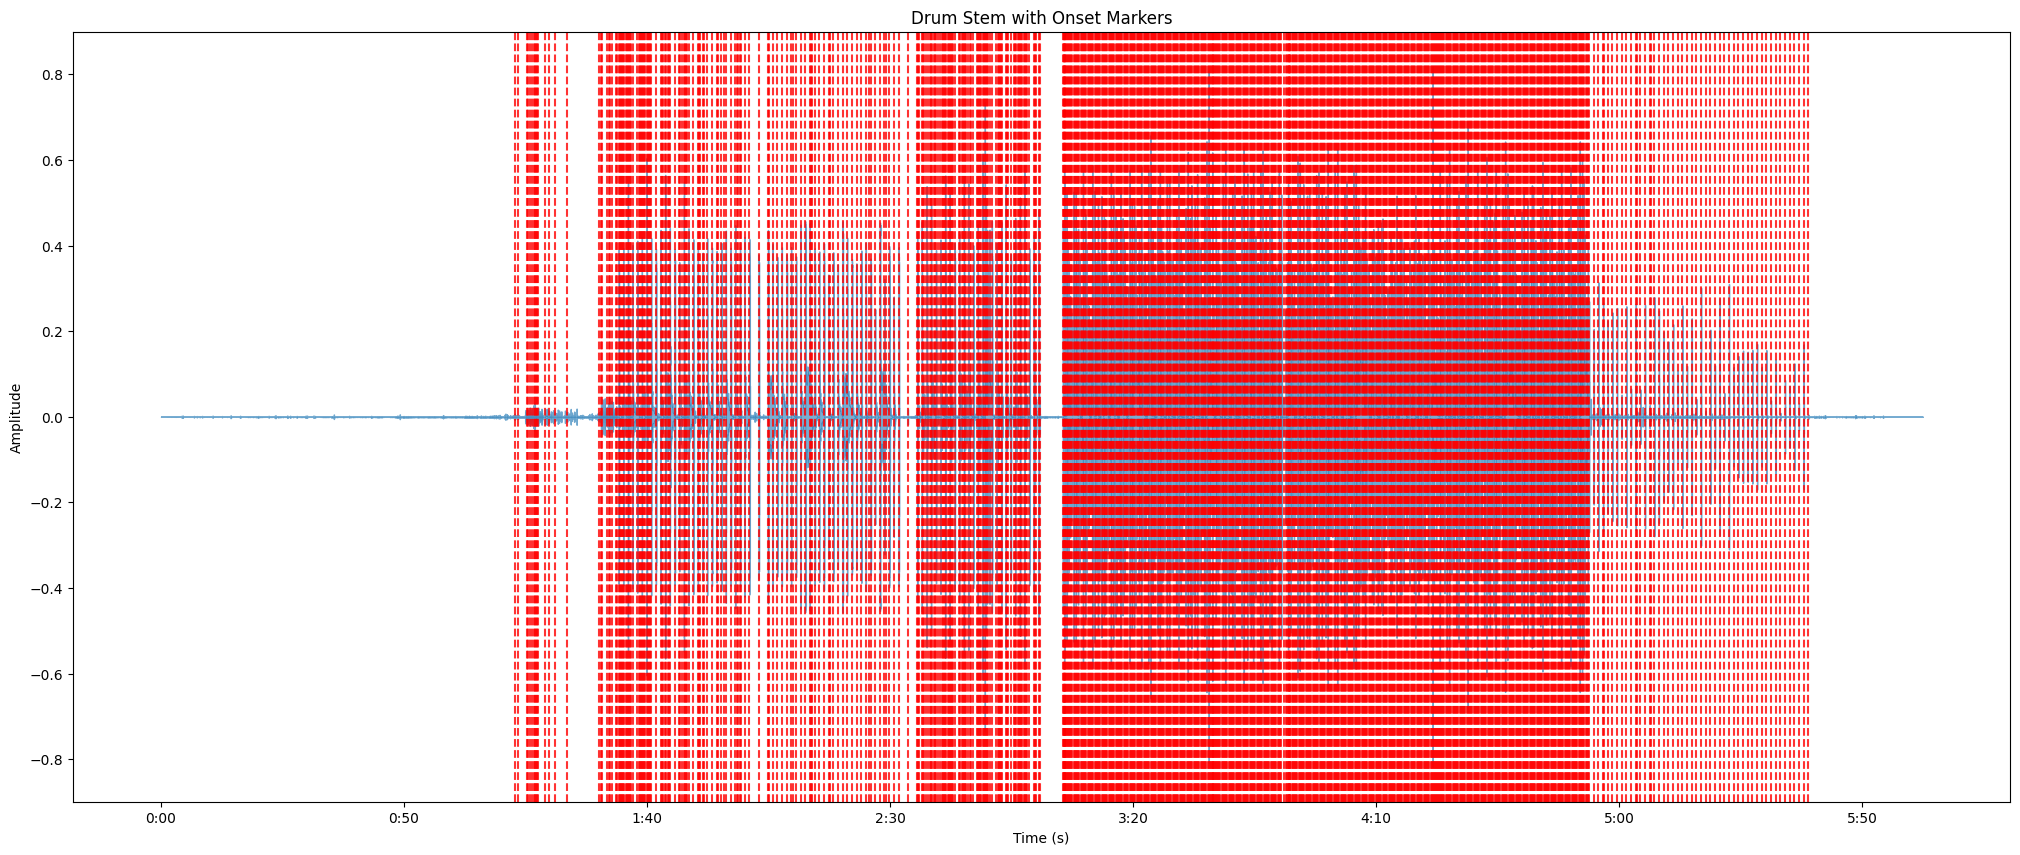

In [35]:
plt.figure(figsize=(25, 10))
librosa.display.waveshow(drums_y, sr=sr, alpha=0.6)

for onset in drums_onset:
    plt.axvline(x=onset, color='r', linestyle='--', alpha=0.8)

plt.title("Drum Stem with Onset Markers")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


In [36]:
other_chroma = librosa.feature.chroma_stft(y=other_y, sr=sr)
other_chroma

array([[0.5935721 , 0.4746003 , 0.36542442, ..., 0.71097094, 0.5522675 ,
        0.526563  ],
       [0.663001  , 0.5856334 , 0.6816664 , ..., 0.5366528 , 0.54925835,
        0.55778956],
       [1.        , 1.        , 1.        , ..., 0.8299606 , 0.5879065 ,
        0.49250883],
       ...,
       [0.8120043 , 0.68296313, 0.3089776 , ..., 0.58666426, 0.792222  ,
        0.93340194],
       [0.73563635, 0.64624953, 0.2658718 , ..., 0.5106743 , 0.63927746,
        0.7487584 ],
       [0.60266364, 0.48939613, 0.2877259 , ..., 0.45959237, 0.46220824,
        0.5465083 ]], shape=(12, 15610), dtype=float32)

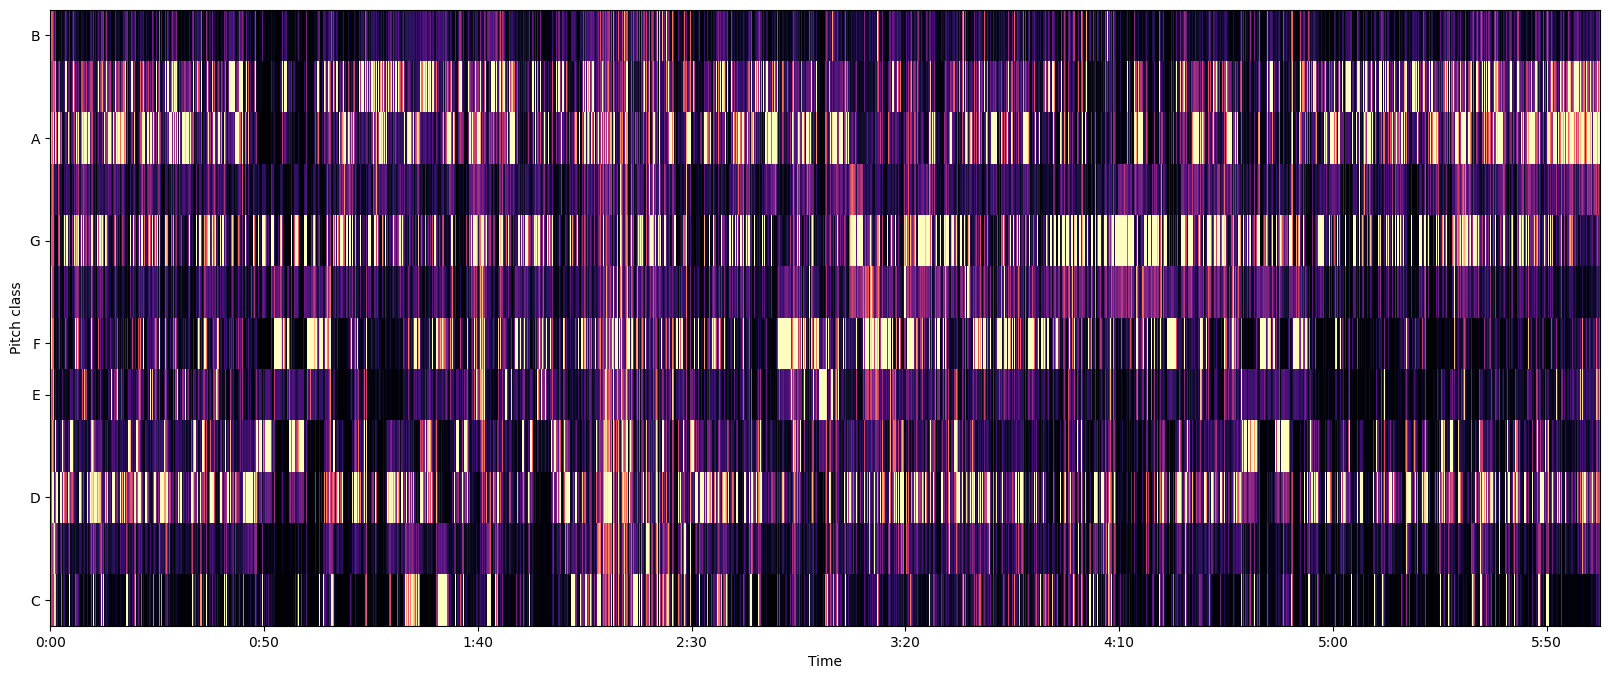

In [51]:

plt.figure(figsize=(20,8))
librosa.display.specshow(other_chroma, x_axis='time' ,y_axis='chroma')